# LASSO

Same setup as `linear_regression.ipynb` but uses LASSO with cross-validated alpha selection (`LassoCV`) on the training set at each period. The key question vs OLS: does L1 regularization recover any signal by shrinking noisy coefficients to zero?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LassoCV
from scipy.stats import spearmanr

# ── config ───────────────────────────────────────────────────────────────────
DATA_PATH = "../data/baseline/model_dataset.parquet"
FEATURES = [
    "EarningsYield_zscore",
    "AssetGrowth_zscore",
    "Accruals_zscore",
    "Momentum12_1_zscore",
]
TARGET = "target_forward_return_21d_zscore"
MIN_TRAIN_PERIODS = 12
# LassoCV searches over these alphas; range chosen for z-scored data
ALPHAS = np.logspace(-4, 1, 50)
CV_FOLDS = 5
# ─────────────────────────────────────────────────────────────────────────────

## Load data

In [2]:
df = pd.read_parquet(DATA_PATH)
df = df.sort_values("signal_date").reset_index(drop=True)

dates = df["signal_date"].sort_values().unique()
print(
    f"{len(dates)} cross-section dates | {df['ticker'].nunique()} tickers | {len(df):,} rows"
)
df.head(3)

95 cross-section dates | 494 tickers | 45,201 rows


,ticker,signal_date,EarningsYield_zscore,AssetGrowth_zscore,Accruals_zscore,Momentum12_1_zscore,target_forward_return_21d_zscore
0,A,2015-01-30,-0.307394,-0.513103,0.094947,-1.089900,0.792406
1,NWSA,2015-01-30,2.628299,-0.242187,0.039993,-1.160230,1.291230
2,NWS,2015-01-30,2.747612,-0.242187,0.039993,-1.241683,1.319400


## Walk-forward validation

In [4]:
records = []

for i, test_date in enumerate(dates):
    if i < MIN_TRAIN_PERIODS:
        continue

    train_mask = df["signal_date"] < test_date
    test_mask = df["signal_date"] == test_date

    X_train = df.loc[train_mask, FEATURES].values
    y_train = df.loc[train_mask, TARGET].values
    X_test = df.loc[test_mask, FEATURES].values
    y_test = df.loc[test_mask, TARGET].values

    # LassoCV selects alpha via k-fold CV on the training set
    model = LassoCV(alphas=ALPHAS, cv=CV_FOLDS, max_iter=5000, fit_intercept=True)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    ic, _ = spearmanr(y_pred, y_test)
    rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
    n_nonzero = np.sum(model.coef_ != 0)

    records.append(
        {
            "date": test_date,
            "IC": ic,
            "RMSE": rmse,
            "alpha": model.alpha_,
            "n_nonzero": n_nonzero,
            "coef_EY": model.coef_[0],
            "coef_AG": model.coef_[1],
            "coef_Acc": model.coef_[2],
            "coef_Mom": model.coef_[3],
        }
    )

results = pd.DataFrame(records).set_index("date")
print(f"Walk-forward results: {len(results)} test periods")
results.head()

/tmp/ipykernel_1153266/461351129.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, _ = spearmanr(y_pred, y_test)
/tmp/ipykernel_1153266/461351129.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, _ = spearmanr(y_pred, y_test)
/tmp/ipykernel_1153266/461351129.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, _ = spearmanr(y_pred, y_test)
/tmp/ipykernel_1153266/461351129.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, _ = spearmanr(y_pred, y_test)
/tmp/ipykernel_1153266/461351129.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, _ = spearmanr(y_pred, y_test)
/tmp/ipykernel_1153266/461351129.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, _ = spearm

Walk-forward results: 83 test periods


/tmp/ipykernel_1153266/461351129.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, _ = spearmanr(y_pred, y_test)
/tmp/ipykernel_1153266/461351129.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, _ = spearmanr(y_pred, y_test)


,IC,RMSE,alpha,n_nonzero,coef_EY,coef_AG,coef_Acc,coef_Mom
date,,,,,,,,
2016-01-29,-0.227799,1.015467,0.017575,2,-0.0,0.0,0.017374,0.06143
2016-02-29,NaN,0.998915,10.000000,0,0.0,0.0,0.000000,0.00000
2016-03-31,NaN,0.998917,10.000000,0,0.0,0.0,0.000000,0.00000
2016-04-29,NaN,0.998917,10.000000,0,0.0,0.0,0.000000,0.00000
2016-05-31,NaN,0.998917,10.000000,0,0.0,0.0,0.000000,0.00000


## Summary statistics

In [5]:
ic = results["IC"]
mean_ic = ic.mean()
icir = mean_ic / ic.std()

print(f"Mean IC      : {mean_ic:.4f}")
print(f"IC StdDev    : {ic.std():.4f}")
print(f"ICIR         : {icir:.4f}")
print(f"IC > 0       : {(ic > 0).mean():.1%} of periods")
print(f"IC > 0.05    : {(ic > 0.05).mean():.1%} of periods")
print(f"Mean RMSE    : {results['RMSE'].mean():.4f}")
print()
print(f"Median alpha       : {results['alpha'].median():.5f}")
print(f"Mean features kept : {results['n_nonzero'].mean():.1f} / {len(FEATURES)}")
print()
print("Mean coefficients:")
results[["coef_EY", "coef_AG", "coef_Acc", "coef_Mom"]].mean().rename(
    {
        "coef_EY": "EarningsYield",
        "coef_AG": "AssetGrowth",
        "coef_Acc": "Accruals",
        "coef_Mom": "Momentum12_1",
    }
)

Mean IC      : -0.0174
IC StdDev    : 0.1002
ICIR         : -0.1740
IC > 0       : 4.8% of periods
IC > 0.05    : 2.4% of periods
Mean RMSE    : 0.9992

Median alpha       : 10.00000
Mean features kept : 0.1 / 4

Mean coefficients:


EarningsYield    0.000000
AssetGrowth      0.000260
Accruals         0.000209
Momentum12_1     0.000740
dtype: float64

## Plots

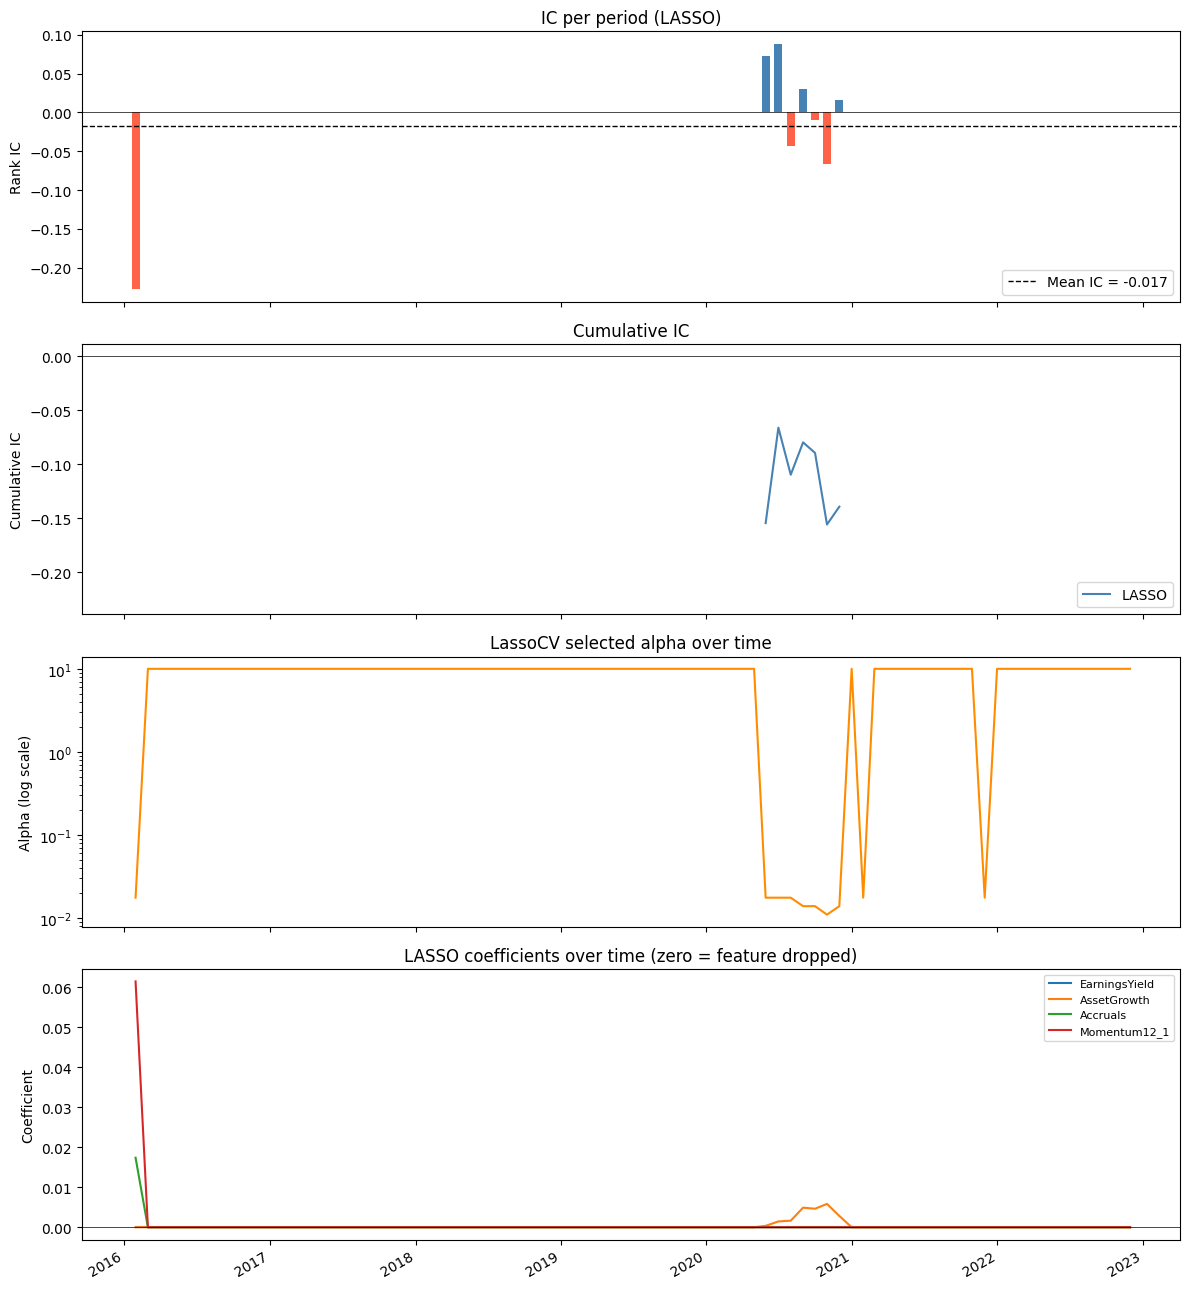

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(12, 13), sharex=True)

# ── IC per period ─────────────────────────────────────────────────────────────
ax = axes[0]
ax.bar(
    results.index,
    results["IC"],
    width=20,
    color=np.where(results["IC"] >= 0, "steelblue", "tomato"),
)
ax.axhline(
    mean_ic,
    color="black",
    linewidth=1,
    linestyle="--",
    label=f"Mean IC = {mean_ic:.3f}",
)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Rank IC")
ax.set_title("IC per period (LASSO)")
ax.legend()

# ── Cumulative IC ─────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(results.index, results["IC"].cumsum(), color="steelblue", label="LASSO")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Cumulative IC")
ax.set_title("Cumulative IC")
ax.legend()

# ── Selected alpha over time ──────────────────────────────────────────────────
ax = axes[2]
ax.plot(results.index, results["alpha"], color="darkorange")
ax.set_ylabel("Alpha (log scale)")
ax.set_yscale("log")
ax.set_title("LassoCV selected alpha over time")

# ── Coefficients over time ────────────────────────────────────────────────────
ax = axes[3]
label_map = {
    "coef_EY": "EarningsYield",
    "coef_AG": "AssetGrowth",
    "coef_Acc": "Accruals",
    "coef_Mom": "Momentum12_1",
}
for col, label in label_map.items():
    ax.plot(results.index, results[col], label=label)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Coefficient")
ax.set_title("LASSO coefficients over time (zero = feature dropped)")
ax.legend(fontsize=8)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())

fig.autofmt_xdate()
plt.tight_layout()
plt.show()